## VeriCirq timing

This notebook measures verification time for some algorithms (adders and a multiplier) to find out what is resonable input size that can be formally verified for different classes of algorithms.

Compared algorithms:

* Cuccarro adder - $2n+1$ qubits, $O(n)$ gates.
* Draper adder - $O(4n)$ qubits,  $O(n)$ gates.
* MCT multiplier - $4n+1$ qubits, $O(n^2)$ gates.

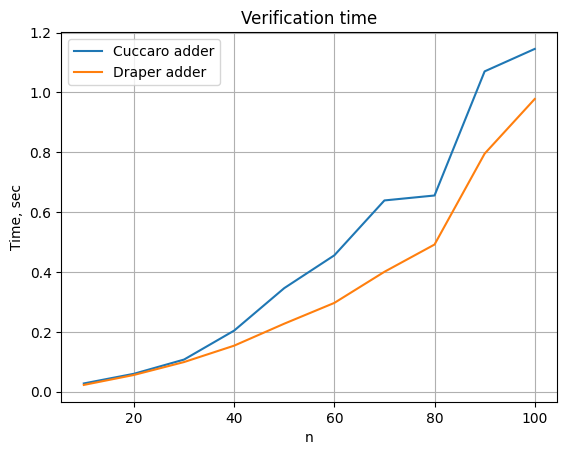

In [42]:
import time
from matplotlib import pyplot as plt

from vericirq.examples.cuccarro_adder import CuccaroAdder, verify_cuccaro_adder
from vericirq.examples.draper_adder import DraperAdder, verify_draper_adder
from vericirq.examples.mct_multiplier import MctMultiplier, verify_mct_multiplier

data = dict()

def add_data_point(data, algo, n, t):
    if algo not in data:
        data[algo] = [[], []]
    data[algo][0].append(n)
    data[algo][1].append(t)

def show_charts(data):
    for algo, chart in data.items():
        plt.plot(chart[0], chart[1], label=algo)
    plt.xlabel("n")
    plt.ylabel("Time, sec")
    plt.legend()
    plt.grid()
    plt.title("Verification time")
    plt.show()

data=dict()
for n in range(10, 101, 10):
    t0 = time.time()
    verify_cuccaro_adder(CuccaroAdder(n))
    add_data_point(data, "Cuccaro adder", n, time.time() - t0)

    t0 = time.time()
    verify_draper_adder(DraperAdder(n))
    add_data_point(data, "Draper adder", n, time.time() - t0)

show_charts(data)

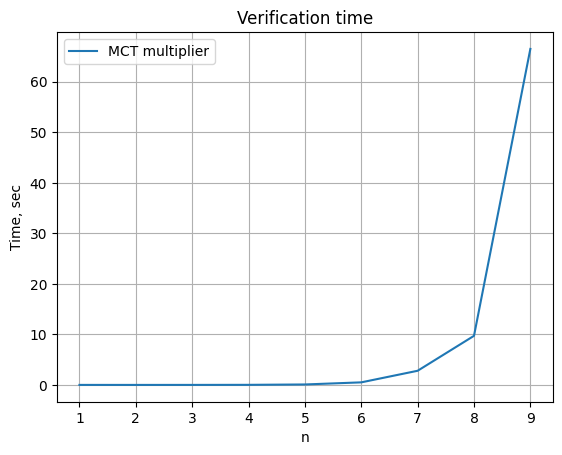

In [43]:
data = dict()
for n in range(1, 10):
    t0 = time.time()
    verify_mct_multiplier(MctMultiplier(n, n))
    add_data_point(data, "MCT multiplier", n, time.time() - t0)
show_charts(data)

### Conclusion

* If we want verification to be O(1 second), for linear algorithms we can verify input sizes up to 100.
* For quadratic algorithms, maximal input size will be in range 5-10 and depends on the algorithm. This is still good enough to get high confidence in algorithm correctness.